In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

import scanpy as sc 

In [2]:

# import importlib
# import SingleCellArchetype
# importlib.reload(SingleCellArchetype)
# importlib.reload(SingleCellArchetype.main)
# importlib.reload(SingleCellArchetype.utils)

from SingleCellArchetype.main import SCA
from SingleCellArchetype.utils import plot_archetype
from SingleCellArchetype.utils import get_relative_variation
from SingleCellArchetype.utils import shuffle_rows_per_col

# Load data

In [3]:
%%time
f_anndata_in = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_dev_v1/DevVIS_multiome_snRNA_processed_sst_adult.h5ad'
adata_hvg = sc.read(f_anndata_in)
adata_hvg

CPU times: user 42.8 ms, sys: 151 ms, total: 194 ms
Wall time: 234 ms


AnnData object with n_obs × n_vars = 1149 × 4880
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'
    obsm: 'pca_later'
    layers: 'lognorm', 'norm', 'zlognorm'

In [4]:
genes_hvg = adata_hvg.var.index.values

# Need to remove PC1!!!

# Run SingleCellArchetype with different controls
- HVG (nHVGs) 
- PCA (ndim)
- number of archetypes (noc)
- level of pointedness (t-ratio)
- level of continuity (within type shuffling)
- enriched programs

In [5]:
from sklearn.decomposition import PCA

In [6]:
# types = [0]*len(adata_hvg)
types = adata_hvg.obs.cluster_label.cat.codes
norm_mat = np.array(adata_hvg.layers['lognorm'])
sca = SCA(norm_mat, types)

In [7]:
x = norm_mat # [:,:300]
n_repeats = 20

nc, ng = x.shape
nc, ng, x.shape

(1149, 4880, (1149, 4880))

In [8]:
pca = PCA(n_components=10).fit(x)

shuffled_evs = []
for i in np.arange(n_repeats):
    x_gshuff = shuffle_rows_per_col(x)
    pca_gshuff = PCA(n_components=10).fit(x_gshuff)
    shuffled_evs.append(pca_gshuff.explained_variance_ratio_)

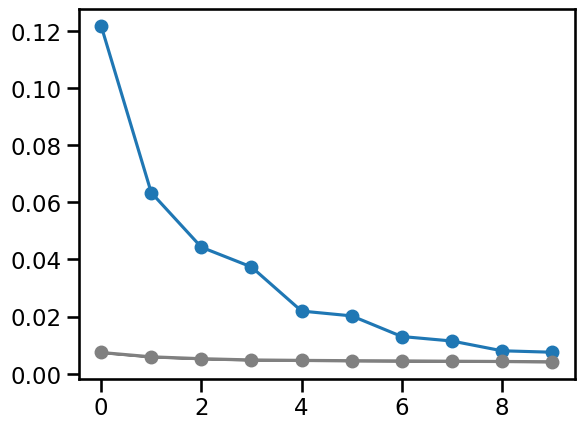

In [9]:
avg = np.mean(shuffled_evs, axis=0)
std = np.std(shuffled_evs, axis=0)

plt.plot(np.arange(10), pca.explained_variance_ratio_, '-o')
plt.plot(np.arange(10), avg, '-o', color='gray')
plt.fill_between(np.arange(10), 
                 avg-std, 
                 avg+std,
                 color='gray')

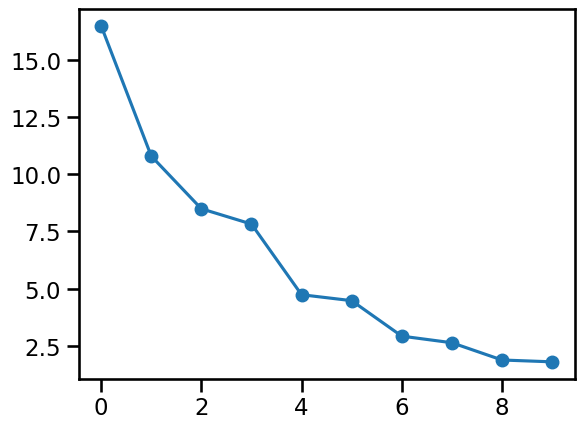

In [10]:
plt.plot(pca.explained_variance_ratio_/avg, '-o')

In [ ]:
ndim = 10 
nrepeats = 10

np.random.seed(0)

skip_pc1 = True
noc_grid = np.arange(2, ndim+2) 
ev_grid = []
av_grid = []

sca.setup_feature_matrix(method='data')
for noc in noc_grid:
    xp, aa, ev = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1)
    
    aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)
    av = get_relative_variation(aa_boots)
    
    print(noc, ev, av)
    ev_grid.append(ev)
    av_grid.append(av)
    
ev_grid = np.array(ev_grid)
av_grid = np.array(av_grid)

use data
2 0.2684603693128217 0.029456456542628042
3 0.4500983813305719 0.0645075680898446
4 0.5763649983007375 0.21871538866512924
5 0.6574965251429051 0.5874696577448153
6 0.7211166472059015 0.7535800812304705
7 0.7658017104965783 0.9721214024207768


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(1*5,1*4))
pf = 10

ax.plot(noc_grid[:pf], ev_grid[:pf], '-o', label='explained variance (EV)')
ax.plot(noc_grid[:pf], av_grid[:pf], '-o', color='gray', label='archetype relative variation (ARV)')
ax.plot(noc_grid[:pf], ev_grid[:pf]*(1-av_grid[:pf]), '-o', label='effective EV')
ax.set_xlabel('noc')
ax.set_ylabel('explained variance')
ax.set_ylim([0,1])
ax.legend(bbox_to_anchor=(1,1))


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(1*5,1*4))
pf = 5

ax.plot(noc_grid[:pf], ev_grid[:pf], '-o', label='explained variance (EV)')
ax.plot(noc_grid[:pf], av_grid[:pf], '-o', color='gray', label='archetype relative variation (ARV)')
ax.plot(noc_grid[:pf], ev_grid[:pf]*(1-av_grid[:pf]), '-o', label='effective EV')
ax.set_xlabel('noc')
ax.set_ylabel('explained variance')
ax.legend(bbox_to_anchor=(1,1))


In [ ]:
noc  = 3 
ndim = noc-1
nrepeats = 3

In [ ]:
# data 
sca.setup_feature_matrix(method='data')
xp, aa, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=True) #skip_pc1)
aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

In [ ]:
# gshuff
sca.setup_feature_matrix(method='gshuff')
xp_gshuff, aa_gshuff, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1)
aa_gshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

In [ ]:
# tshuff 
sca.setup_feature_matrix(method='tshuff')
xp_tshuff, aa_tshuff, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1)
aa_tshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

## plot

In [ ]:
types_colorvec = np.char.add('C', sca.types_idx.astype(str))

In [ ]:
# plot
fig, axs = plt.subplots(1,3,figsize=(8*3,6))
ax = axs[0]
ax.scatter(xp[:,0], xp[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    
ax = axs[1]
ax.set_title('Shuffled')
ax.scatter(xp_gshuff[:,0], xp_gshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_gshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_gshuff_boots[i], fmt='--', color='gray', zorder=0)

ax = axs[2]
ax.set_title('Shuffled within each type')
ax.scatter(xp_tshuff[:,0], xp_tshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_tshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_tshuff_boots[i], fmt='--', color='gray', zorder=0)

for i in range(3):
    ax = axs[i]
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal')
    sns.despine(ax=ax)
    ax.grid(False)
    
plt.show()

In [ ]:
adata_hvg.obs.cluster_label

## quantify the level of pointedness 
- t-ratio 

In [ ]:
t_ratio, t_ratio_shuffs, pval = sca.t_ratio_test(ndim, noc, skip_pc1=True, nrepeats=100)
print(f'p-value: {pval}')

In [ ]:
fig, ax = plt.subplots()
ax.axvline(t_ratio, color='r', label='data')
sns.histplot(t_ratio_shuffs, ax=ax, stat='density', label='shuffled')
ax.set_xlabel('t-ratio')
ax.legend()
sns.despine(ax=ax)
plt.show()

# local gradient 

In [ ]:
adata_dpt = adata_hvg
skip_pc1 = True
if skip_pc1:
    adata_dpt.obsm['pca_later'] = PCA(n_components=10).fit_transform(sca.xn)[:,1:]
adata_dpt

In [ ]:
pc1 = adata_dpt.obsm['pca_later'][:,0]
pc2 = adata_dpt.obsm['pca_later'][:,1]
gexp = np.array(adata_dpt[:,'Cdh13'].layers['norm']).reshape(-1,)

sc.pp.neighbors(adata_dpt, n_neighbors=30, use_rep='pca_later')
# adata_dpt.uns["iroot"] = np.argmax(gexp) 
adata_dpt.uns["iroot"] = np.argmax(pc1-pc2)
sc.tl.diffmap(adata_dpt)
sc.tl.dpt(adata_dpt)

In [ ]:
adata_dpt

In [ ]:
num_bins = 100
xm = (1/2 + np.arange(0,num_bins,1))*1/num_bins
adata_dpt.obs['dpt'] = np.clip(adata_dpt.obs['dpt_pseudotime'].values, a_min=0, a_max=1)

adata_dpt.obs['dpt_bin']  = pd.cut( adata_dpt.obs['dpt'], num_bins, labels=False)
adata_dpt.obs['dpt_qbin'] = pd.qcut(adata_dpt.obs['dpt'], num_bins, labels=False)

cdf = adata_dpt.obs.groupby('dpt_bin').size()
cdf_by_subclass = adata_dpt.obs.groupby(['dpt_bin', 'cluster_label']).size().unstack()

qcdf = adata_dpt.obs.groupby('dpt_qbin').size()
qcdf_by_subclass = adata_dpt.obs.groupby(['dpt_qbin', 'cluster_label']).size().unstack()

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=adata_dpt.obs['dpt'].values, s=2)
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

In [ ]:
gexp = np.array(adata_dpt[:,'Chrm2'].layers['lognorm']).reshape(-1,)

fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=gexp, s=2, cmap='rocket_r')
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

In [ ]:
x = adata_dpt.obs['dpt'].values
qx = adata_dpt.obs['dpt'].rank(pct=True)

gns = ['Chrm2', 'Cdh13', 'Cdh12', 'Sorcs3']
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.array(adata_dpt[:,gn].layers['norm']).reshape(-1,)
    ax.scatter(x, y, s=3)
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.array(adata_dpt[:,gn].layers['norm']).reshape(-1,)
    ax.scatter(qx, y, s=3)
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()